<a href="https://colab.research.google.com/github/rishi0-405/Python-Data-Analysis-and-Visualization/blob/main/3-days-Workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
"Cricket"
import csv
filename = "/ipl_2023_deliveries.csv"
fields = []
rows = []
with open(filename, 'r') as csvfile:
    csvreader = csv.reader(csvfile)
    # Read header
    fields = next(csvreader)
    # Read remaining rows
    for row in csvreader:
        rows.append(row)
    print("Total no. of rows:", csvreader.line_num)
print("Field names are:", ", ".join(fields))
print("\nFirst five rows are:\n")
for row in rows[:5]:
    for col in row:
        print("%15s" % col, end=" ")
    print()

Total no. of rows: 17387
Field names are: match_id, season, match_no, date, venue, batting_team, bowling_team, innings, over, striker, bowler, runs_of_bat, extras, wide, legbyes, byes, noballs, wicket_type, player_dismissed, fielder

First five rows are:

         202301            2023               1    Mar 31, 2023 Narendra Modi Stadium, Ahmedabad             CSK              GT               1             0.1          Conway           Shami               0               0               0               0               0               0                                                 
         202301            2023               1    Mar 31, 2023 Narendra Modi Stadium, Ahmedabad             CSK              GT               1             0.2          Conway           Shami               0               1               0               1               0               0                                                 
         202301            2023               1    Mar 31, 2023 Nare

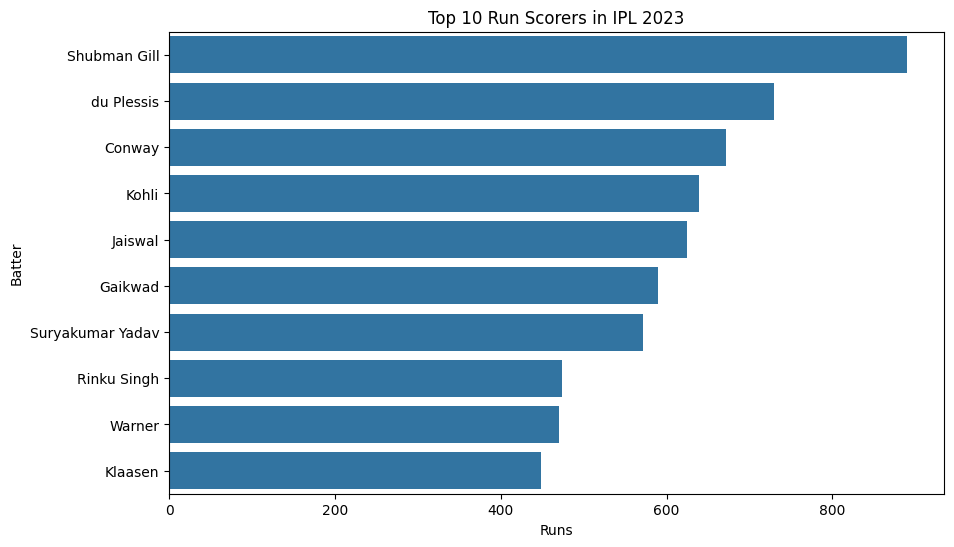

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert list to DataFrame
df = pd.DataFrame(rows, columns=fields)

# Convert runs to numeric
df["runs_of_bat"] = pd.to_numeric(df["runs_of_bat"])

# Total runs by batter
top_batsmen = df.groupby("striker")["runs_of_bat"].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index)

plt.title("Top 10 Run Scorers in IPL 2023")
plt.xlabel("Runs")
plt.ylabel("Batter")
plt.show()

Weather

In [ ]:
import requests
url = "https://api.open-meteo.com/v1/forecast"
# Parameters
params = {
    "latitude": 23.9966,
    "longitude": 85.3691,
    "current_weather": "true"
}
# Send GET request
response = requests.get(url, params=params)
# Check status
print("Status Code:", response.status_code)
# Convert response to JSON
data = response.json()
# Print full response
print("\nFull Response:")
print(data)
weather = data["current_weather"]
print("\nCurrent Weather Details")
print("Temperature:", weather["temperature"], "°C")
print("Wind Speed:", weather["windspeed"], "km/h")
print("Wind Direction:", weather["winddirection"], "°")
print("Weather Code:", weather["weathercode"])
print("Is Day:", weather["is_day"])
print("Time:", weather["time"])

Status Code: 200

Full Response:
{'latitude': 24.007029, 'longitude': 85.32343, 'generationtime_ms': 1.3180971145629883, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 616.0, 'current_weather_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature': '°C', 'windspeed': 'km/h', 'winddirection': '°', 'is_day': '', 'weathercode': 'wmo code'}, 'current_weather': {'time': '2026-07-15T06:15', 'interval': 900, 'temperature': 27.5, 'windspeed': 6.1, 'winddirection': 30, 'is_day': 1, 'weathercode': 95}}

Current Weather Details
Temperature: 27.5 °C
Wind Speed: 6.1 km/h
Wind Direction: 30 °
Weather Code: 95
Is Day: 1
Time: 2026-07-15T06:15


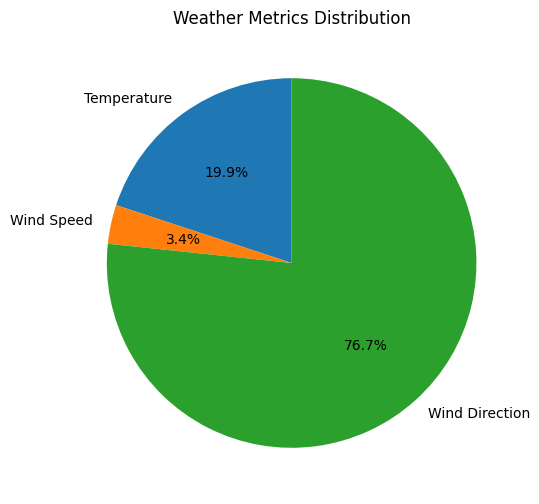

In [21]:
import matplotlib.pyplot as plt
import requests

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 23.9966,
    "longitude": 85.3691,
    "current_weather": "true"
}
response = requests.get(url, params=params)
data = response.json()
weather = data["current_weather"]

labels = ["Temperature", "Wind Speed", "Wind Direction"]
sizes = [
    weather["temperature"],
    weather["windspeed"],
    weather["winddirection"]
]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title("Weather Metrics Distribution")
plt.show()

Weather for every State's Capitols of INDIA

In [ ]:
"""API_WEATHER.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1cX878kWVeTCIhkNmqYPwa_epkA3kB1Uw
"""

!pip install requests pandas

import requests
import pandas as pd
import time

API_KEY = "21d26b4a54e7128929ed2bb80e3e036b"


BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

states = {
    "Andhra Pradesh": "Amaravati",
    "Arunachal Pradesh": "Itanagar",
    "Assam": "Dispur",
    "Bihar": "Patna",
    "Chhattisgarh": "Raipur",
    "Goa": "Panaji",
    "Gujarat": "Gandhinagar",
    "Haryana": "Chandigarh",
    "Himachal Pradesh": "Shimla",
    "Jharkhand": "Ranchi",
    "Karnataka": "Bengaluru",
    "Kerala": "Thiruvananthapuram",
    "Madhya Pradesh": "Bhopal",
    "Maharashtra": "Mumbai",
    "Manipur": "Imphal",
    "Meghalaya": "Shillong",
    "Mizoram": "Aizawl",
    "Nagaland": "Kohima",
    "Odisha": "Bhubaneswar",
    "Punjab": "Chandigarh",
    "Rajasthan": "Jaipur",
    "Sikkim": "Gangtok",
    "Tamil Nadu": "Chennai",
    "Telangana": "Hyderabad",
    "Tripura": "Agartala",
    "Uttar Pradesh": "Lucknow",
    "Uttarakhand": "Dehradun",
    "West Bengal": "Kolkata"
}

weather_list = []

for state, city in states.items():

    # API URL
    url = f"{BASE_URL}?q={city}&appid={API_KEY}&units=metric"

    print("\nAPI URL :")
    print(url)

    # GET REQUEST
    response = requests.get(url)

    # STATUS CODE
    print("Status Code :", response.status_code)

    # SUCCESS
    if response.status_code == 200:

        data = response.json()

        weather_data = {
            "State": state,
            "Capital": city,
            "Temperature": data["main"]["temp"],
            "Feels_Like": data["main"]["feels_like"],
            "Humidity": data["main"]["humidity"],
            "Pressure": data["main"]["pressure"],
            "Weather": data["weather"][0]["description"],
            "Wind_Speed": data["wind"]["speed"],
            "Clouds": data["clouds"]["all"],
            "Visibility": data.get("visibility", "N/A")
        }

        weather_list.append(weather_data)

        print("Data Fetched Successfully")

    else:

        print("API Error")
        print(response.json())

    # Delay
    time.sleep(1)

df = pd.DataFrame(weather_list)


df.to_csv("india_weather_data.csv", index=False)



print("\nComplete Weather Data")
print(df)

print("\nCSV File Saved Successfully")


API URL :
https://api.openweathermap.org/data/2.5/weather?q=Amaravati&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Itanagar&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Dispur&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Patna&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Raipur&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
https://api.openweathermap.org/data/2.5/weather?q=Panaji&appid=21d26b4a54e7128929ed2bb80e3e036b&units=metric
Status Code : 200
Data Fetched Successfully

API URL :
h

/tmp/ipykernel_1759/229876089.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='State', y='Temperature', data=df, palette='viridis')


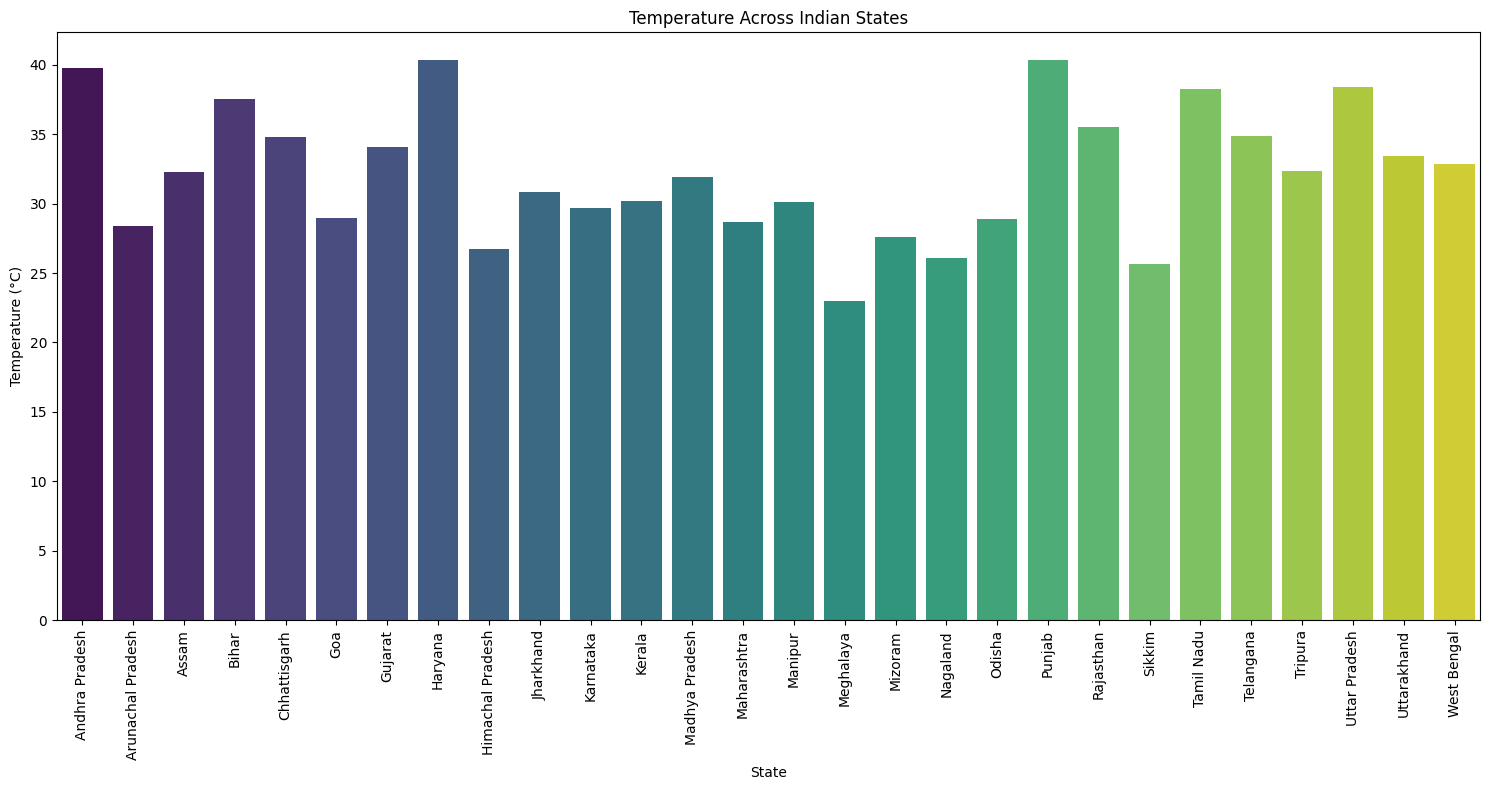

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.barplot(x='State', y='Temperature', data=df, palette='viridis')
plt.xlabel('State')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Across Indian States')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Stock Market Analysis

In [ ]:
"Stock market"

import requests
import pandas as pd
import time

API_KEY = "N0250B19KMLO1BMF"

BASE_URL = "https://www.alphavantage.co/query"

# Indian Stock Symbols
stocks = {
    "Reliance": "RELIANCE.BSE",
    "TCS": "TCS.BSE",
    "Infosys": "INFY.BSE",
    "HDFC Bank": "HDFCBANK.BSE",
    "ICICI Bank": "ICICIBANK.BSE",
    "SBI": "SBIN.BSE",
    "ITC": "ITC.BSE",
    "Wipro": "WIPRO.BSE",
    "Bharti Airtel": "BHARTIARTL.BSE",
    "L&T": "LT.BSE"
}

stock_list = []

for company, symbol in stocks.items():

    url = f"{BASE_URL}?function=GLOBAL_QUOTE&symbol={symbol}&apikey={API_KEY}"

    print("\nAPI URL:")
    print(url)

    response = requests.get(url)

    print("Status Code:", response.status_code)

    if response.status_code == 200:

        data = response.json()

        if "Global Quote" in data and data["Global Quote"]:

            quote = data["Global Quote"]

            stock_data = {
                "Company": company,
                "Symbol": symbol,
                "Price": quote.get("05. price"),
                "Open": quote.get("02. open"),
                "High": quote.get("03. high"),
                "Low": quote.get("04. low"),
                "Previous_Close": quote.get("08. previous close"),
                "Volume": quote.get("06. volume"),
                "Change": quote.get("09. change"),
                "Change_Percent": quote.get("10. change percent")
            }

            stock_list.append(stock_data)

            print("Data Fetched Successfully")

        else:
            print("No Data Found")

    else:
        print("API Error")

    time.sleep(12)

df = pd.DataFrame(stock_list)

df.to_csv("stock_market_data.csv", index=False)

print("\nStock Market Data")
print(df)

print("\nCSV File Saved Successfully")





API URL:
https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol=RELIANCE.BSE&apikey=N0250B19KMLO1BMF
Status Code: 200
Data Fetched Successfully

API URL:
https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol=TCS.BSE&apikey=N0250B19KMLO1BMF
Status Code: 200
Data Fetched Successfully

API URL:
https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol=INFY.BSE&apikey=N0250B19KMLO1BMF
Status Code: 200
Data Fetched Successfully

API URL:
https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol=HDFCBANK.BSE&apikey=N0250B19KMLO1BMF
Status Code: 200
Data Fetched Successfully

API URL:
https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol=ICICIBANK.BSE&apikey=N0250B19KMLO1BMF
Status Code: 200
Data Fetched Successfully

API URL:
https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol=SBIN.BSE&apikey=N0250B19KMLO1BMF
Status Code: 200
Data Fetched Successfully

API URL:
https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol=ITC.BSE&apikey=N0250B

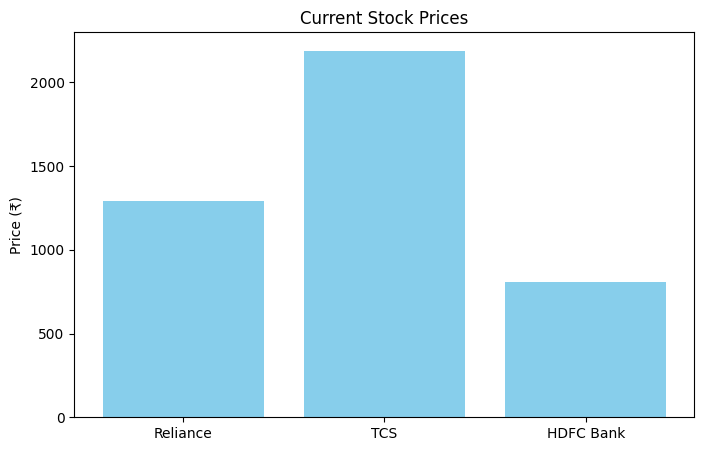

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import time

# API Setup
API_KEY = "N0250B19KMLO1BMF"
BASE_URL = "https://www.alphavantage.co/query"
stocks = {"Reliance": "RELIANCE.BSE", "TCS": "TCS.BSE", "HDFC Bank": "HDFCBANK.BSE"}
stock_list = []

for company, symbol in stocks.items():
    url = f"{BASE_URL}?function=GLOBAL_QUOTE&symbol={symbol}&apikey={API_KEY}"
    data = requests.get(url).json().get("Global Quote", {})
    if data:
        stock_list.append({"Company": company, "Price": float(data.get("05. price", 0))})
    time.sleep(12)  # API rate limit buffer

# Plotting
df = pd.DataFrame(stock_list)
plt.figure(figsize=(8, 5))
plt.bar(df["Company"], df["Price"], color='skyblue')
plt.title("Current Stock Prices")
plt.ylabel("Price (₹)")
plt.show()